In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

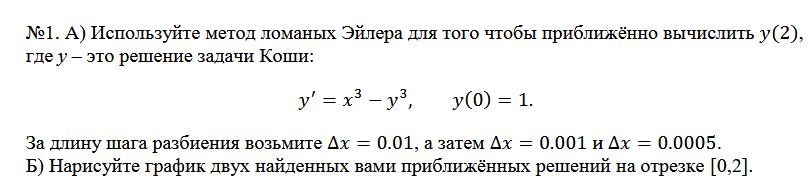

А) Приближённые значения y(2):
При Δx = 0.01  : y(2) ≈ 1.900020
При Δx = 0.001 : y(2) ≈ 1.899853
При Δx = 0.0005: y(2) ≈ 1.899844


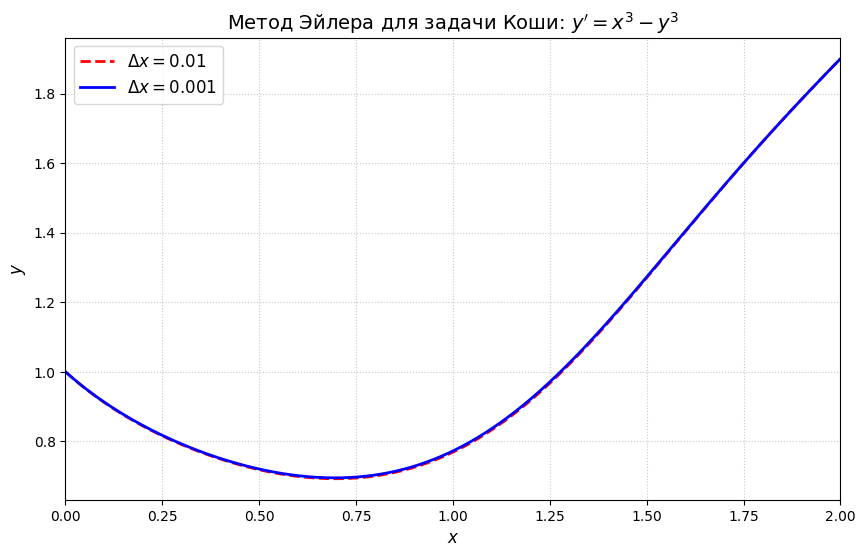

In [6]:
def f(x, y):
    return x**3 - y**3

def euler_method(f, x0, y0, x_end, dx):
    n_steps = int(np.round((x_end - x0) / dx))
    
    x = np.linspace(x0, x_end, n_steps + 1)
    y = np.zeros(n_steps + 1)
    
    y[0] = y0
    
    for i in range(n_steps):
        y[i+1] = y[i] + dx * f(x[i], y[i])
        
    return x, y

x0 = 0.0
y0 = 1.0
x_end = 2.0
dx_values = [0.01, 0.001, 0.0005]
results = {}

print("А) Приближённые значения y(2):")

for dx in dx_values:
    x_vals, y_vals = euler_method(f, x0, y0, x_end, dx)
    results[dx] = (x_vals, y_vals)
    print(f"При Δx = {dx:<6}: y(2) ≈ {y_vals[-1]:.6f}")

plt.figure(figsize=(10, 6))
dx_to_plot = [0.01, 0.001]
colors = ['red', 'blue']
line_styles = ['--', '-']

for dx, color, style in zip(dx_to_plot, colors, line_styles):
    x_vals, y_vals = results[dx]
    plt.plot(x_vals, y_vals, label=f'$\\Delta x = {dx}$', 
             color=color, linestyle=style, linewidth=2)

plt.title("Метод Эйлера для задачи Коши: $y' = x^3 - y^3$", fontsize=14)
plt.xlabel('$x$', fontsize=12)
plt.ylabel('$y$', fontsize=12)
plt.xlim(x0, x_end)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

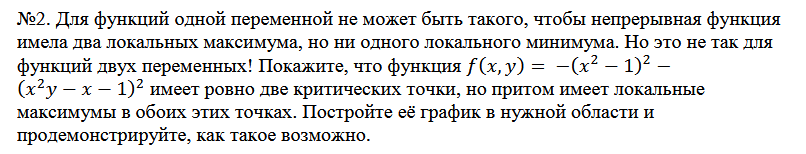

Исследование точки M(-1, 0):
  Результат: ЛОКАЛЬНЫЙ МАКСИМУМ

Исследование точки M(1, 2):
  Результат: ЛОКАЛЬНЫЙ МАКСИМУМ



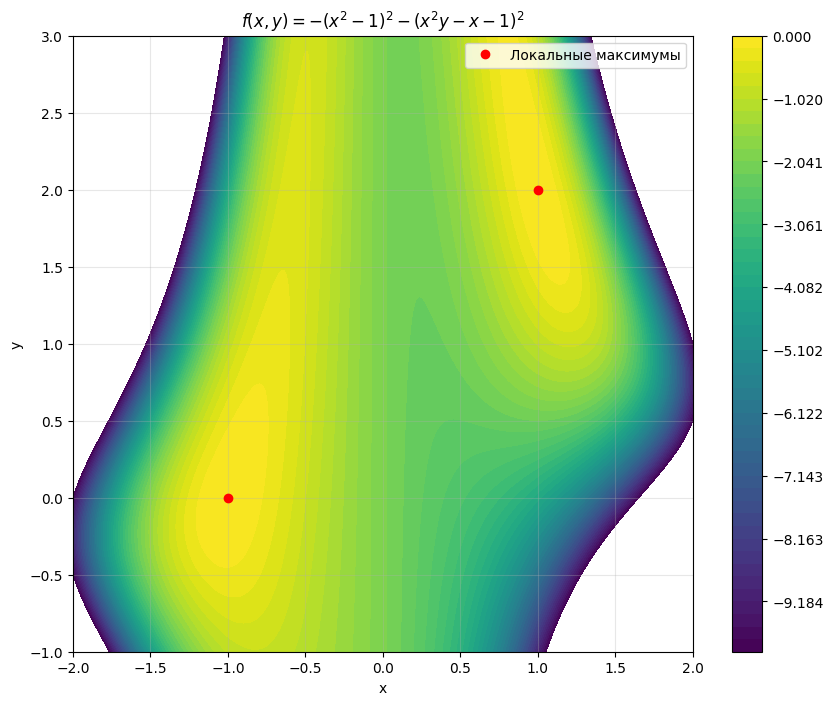

In [9]:
x, y = sp.symbols('x y', real=True)
f = -(x**2 - 1)**2 - (x**2 * y - x - 1)**2
grad = [sp.diff(f, var) for var in (x, y)]
critical_points = sp.solve(grad, (x, y))

H = sp.hessian(f, (x, y))

for point in critical_points:
    x_v, y_v = point
    H_at_point = H.subs({x: x_v, y: y_v})
    delta1 = H_at_point[0, 0]
    delta2 = H_at_point.det()
    
    print(f"Исследование точки M({x_v}, {y_v}):")
    
    if delta1 < 0 and delta2 > 0:
        print("  Результат: ЛОКАЛЬНЫЙ МАКСИМУМ")
    
    elif delta1 > 0 and delta2 > 0:
        print("  Результат: ЛОКАЛЬНЫЙ МИНИМУМ")
        
    elif delta2 < 0:
        print("  Результат: СЕДЛОВАЯ ТОЧКА")
    else:
        print("  Результат: Необходим дополнительный анализ")
    print()

def f(x, y):
    return -(x**2 - 1)**2 - (x**2 * y - x - 1)**2

x = np.linspace(-2, 2, 400)
y = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

plt.figure(figsize=(10, 8))
cp = plt.contourf(X, Y, Z, levels=np.linspace(-10, 0, 50), cmap='viridis')
plt.colorbar(cp)
plt.plot([1, -1], [2, 0], 'ro', label='Локальные максимумы')
plt.title(f'$f(x, y) = -(x^2-1)^2 - (x^2y-x-1)^2$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

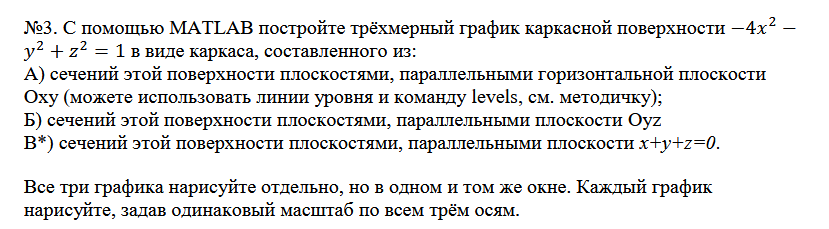

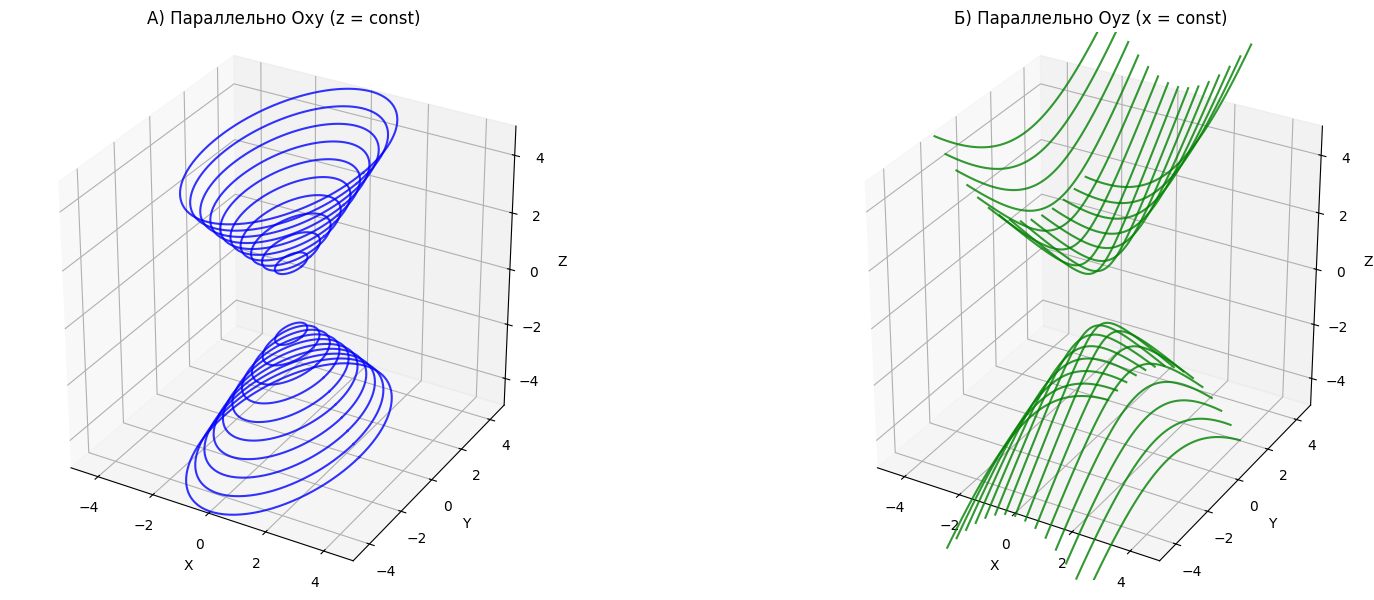

In [32]:
fig = plt.figure(figsize=(18, 6))
limits = [-5, 5]

ax1 = fig.add_subplot(121, projection='3d')
ax1.set_title("А) Параллельно Oxy (z = const)")
z_vals = np.linspace(-5, 5, 25)
for z in z_vals:
    if abs(z) >= 1.05:  
        r = np.sqrt(z**2 - 1)
        t = np.linspace(0, 2*np.pi, 100)
        x = (r / 2) * np.cos(t)
        y = r * np.sin(t)
        ax1.plot(x, y, z, color='blue', alpha=0.8)

ax2 = fig.add_subplot(122, projection='3d')
ax2.set_title("Б) Параллельно Oyz (x = const)")
x_vals = np.linspace(-2.5, 2.5, 15)
for x in x_vals:
    c2 = 1 + 4*x**2
    y = np.linspace(-5, 5, 100)
    z_pos = np.sqrt(y**2 + c2)
    z_neg = -np.sqrt(y**2 + c2)
    ax2.plot(np.full_like(y, x), y, z_pos, color='green', alpha=0.8)
    ax2.plot(np.full_like(y, x), y, z_neg, color='green', alpha=0.8)

for ax in [ax1, ax2]:
    ax.set_xlim(limits)
    ax.set_ylim(limits)
    ax.set_zlim(limits)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_box_aspect([1, 1, 1]) 

plt.tight_layout()
plt.show()

     2          2    
- 4⋅x  + (C - x)  - 1
─────────────────────
      2⋅(C - x)      


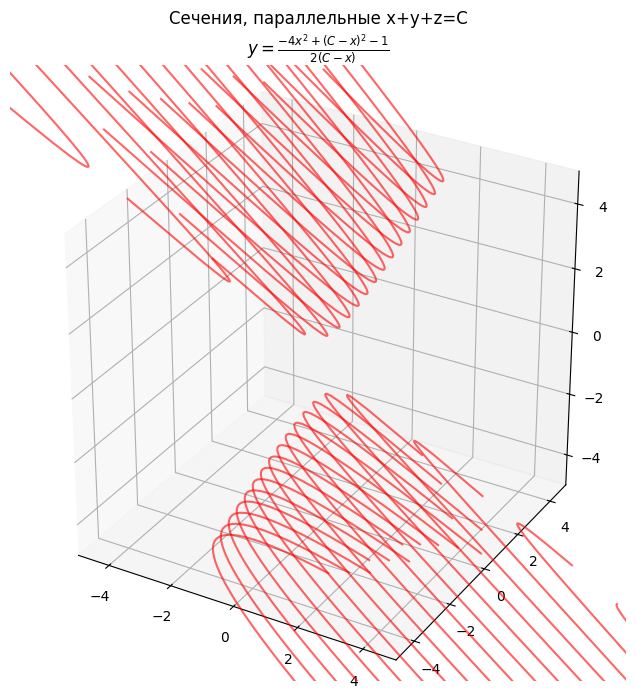

In [33]:
x_sym, y_sym, z_sym, C_sym = sp.symbols('x y z C')

surface_eq = -4*x_sym**2 - y_sym**2 + z_sym**2 - 1
plane_z = C_sym - x_sym - y_sym

substituted_eq = surface_eq.subs(z_sym, plane_z)
y_expr = sp.solve(substituted_eq, y_sym)[0]

sp.pprint(y_expr)
y_func = sp.lambdify((x_sym, C_sym), y_expr, 'numpy')

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
limits = [-5, 5]

c_vals = np.linspace(-9.8, 9.8, 30)
eps = 0.1

for c in c_vals:  
    for x_range in [np.linspace(-10, c - eps, 100), np.linspace(c + eps, 10, 100)]:
        y_vals = y_func(x_range, c)
        z_vals = c - x_range - y_vals
        
        mask = (np.abs(y_vals) < 15) & (np.abs(z_vals) < 15)
        ax.plot(x_range[mask], y_vals[mask], z_vals[mask], color='red', alpha=0.6)

ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_zlim(limits)
ax.set_title(f"Сечения, параллельные x+y+z=C\n$y = {sp.latex(y_expr)}$")
ax.set_box_aspect([1,1,1])
plt.show()

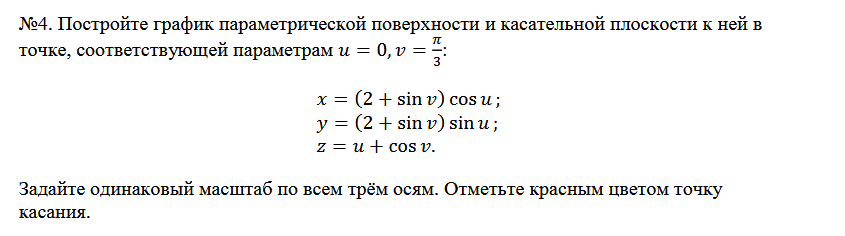

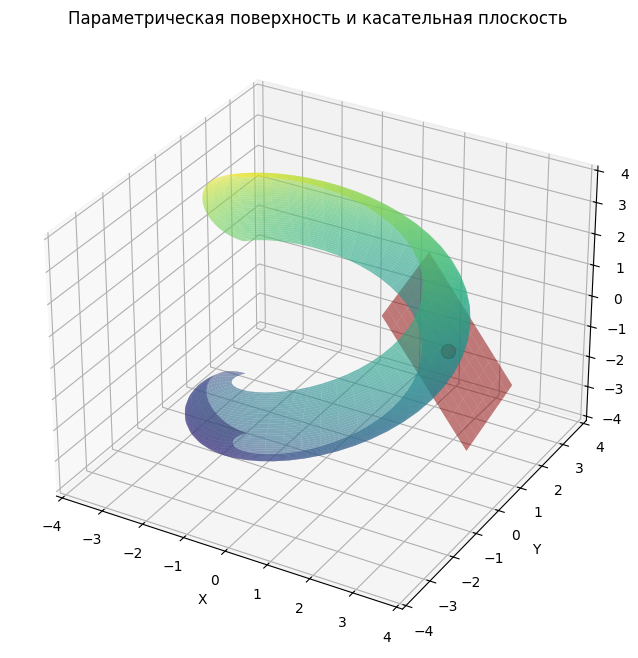

In [34]:
def get_surface(u, v):
    x = (2 + np.sin(v)) * np.cos(u)
    y = (2 + np.sin(v)) * np.sin(u)
    z = u + np.cos(v)
    return x, y, z

u = np.linspace(-np.pi, np.pi, 50)
v = np.linspace(0, np.pi, 50)
U, V = np.meshgrid(u, v)
X, Y, Z = get_surface(U, V)

u0, v0 = 0, np.pi/3
x0, y0, z0 = get_surface(u0, v0)

ru = np.array([-(2 + np.sin(v0))*np.sin(u0), (2 + np.sin(v0))*np.cos(u0), 1])
rv = np.array([np.cos(v0)*np.cos(u0), np.cos(v0)*np.sin(u0), -np.sin(v0)])
n = np.cross(ru, rv) # Вектор нормали

x_p = np.linspace(x0-1, x0+1, 10)
y_p = np.linspace(y0-1, y0+1, 10)
X_p, Y_p = np.meshgrid(x_p, y_p)
Z_p = z0 - (n[0]*(X_p - x0) + n[1]*(Y_p - y0)) / n[2]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, alpha=0.6, cmap='viridis')

ax.plot_surface(X_p, Y_p, Z_p, color='red', alpha=0.5, label='Касательная плоскость')
ax.scatter([x0], [y0], [z0], color='red', s=100, edgecolors='black', label='Точка касания')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Параметрическая поверхность и касательная плоскость')

max_range = np.array([X.max()-X.min(), Y.max()-Y.min(), Z.max()-Z.min()]).max() / 2.0
mid_x = (X.max()+X.min()) * 0.5
mid_y = (Y.max()+Y.min()) * 0.5
mid_z = (Z.max()+Z.min()) * 0.5
ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

plt.show()

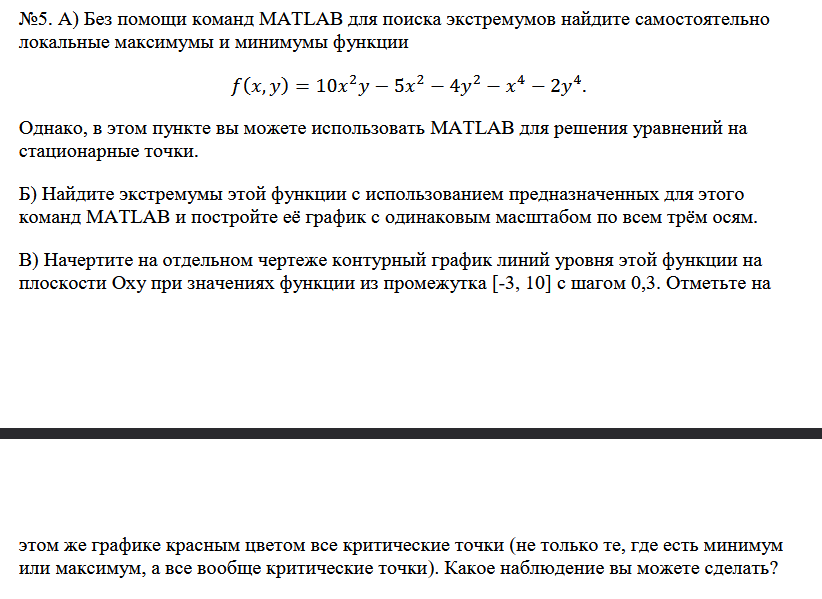

df/dx: -4*x**3 + 20*x*y - 10*x
df/dy: 10*x**2 - 8*y**3 - 8*y
Критические точки (x, y):
(0.000, 0.000)


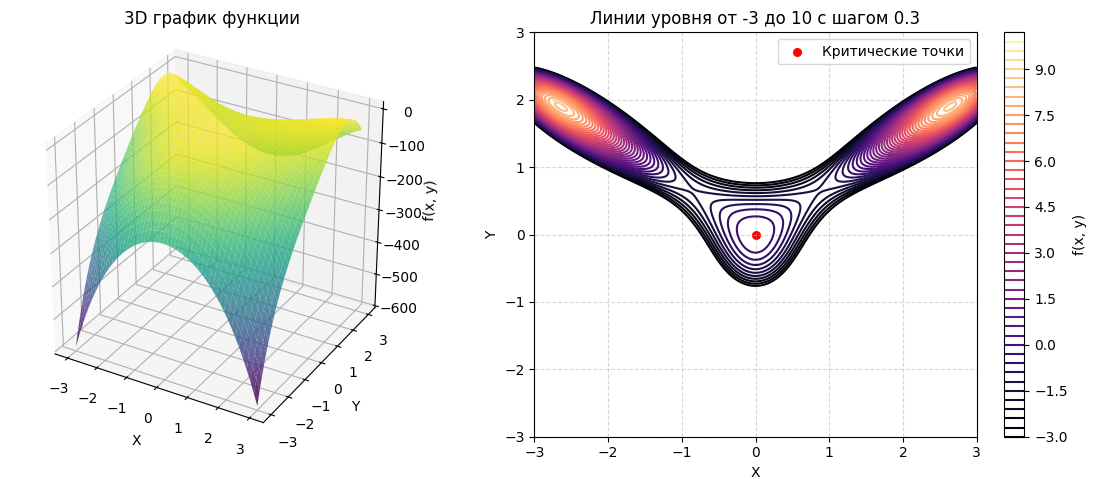

In [41]:
x, y = sp.symbols('x y')
f = 10*x**2*y - 5*x**2 - 4*y**2 - x**4 - 2*y**4
df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)
print("df/dx:", df_dx)
print("df/dy:", df_dy)

critical_points_test = sp.solve([df_dx, df_dy], (x, y))
critical_points = [p for p in critical_points_test if p[0].is_real and p[1].is_real]
print("Критические точки (x, y):")
for p in critical_points:
    print(f"({float(p[0]):.3f}, {float(p[1]):.3f})")

f_func = sp.lambdify((x, y), f, 'numpy')
x_vals = np.linspace(-3, 3, 400)
y_vals = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = f_func(X, Y)

fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax1.set_title('3D график функции')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('f(x, y)')
ax1.set_box_aspect([1,1,1]) 

ax2 = fig.add_subplot(122)
levels = np.arange(-3, 10.3, 0.3)
contour = ax2.contour(X, Y, Z, levels=levels, cmap='magma')
plt.colorbar(contour, ax=ax2, label='f(x, y)')

cp_x = [float(p[0]) for p in critical_points]
cp_y = [float(p[1]) for p in critical_points]
ax2.scatter(cp_x, cp_y, color='red', s=30, label='Критические точки')

ax2.set_title('Линии уровня от -3 до 10 с шагом 0.3')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

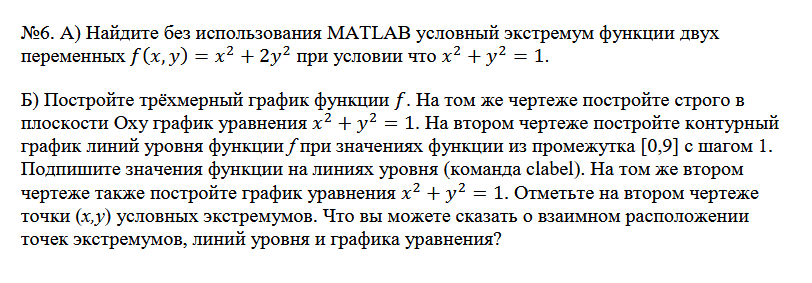

Точки условного экстремума:
Точка: (-1, 0), Значение f: 1
Точка: (1, 0), Значение f: 1
Точка: (0, -1), Значение f: 2
Точка: (0, 1), Значение f: 2


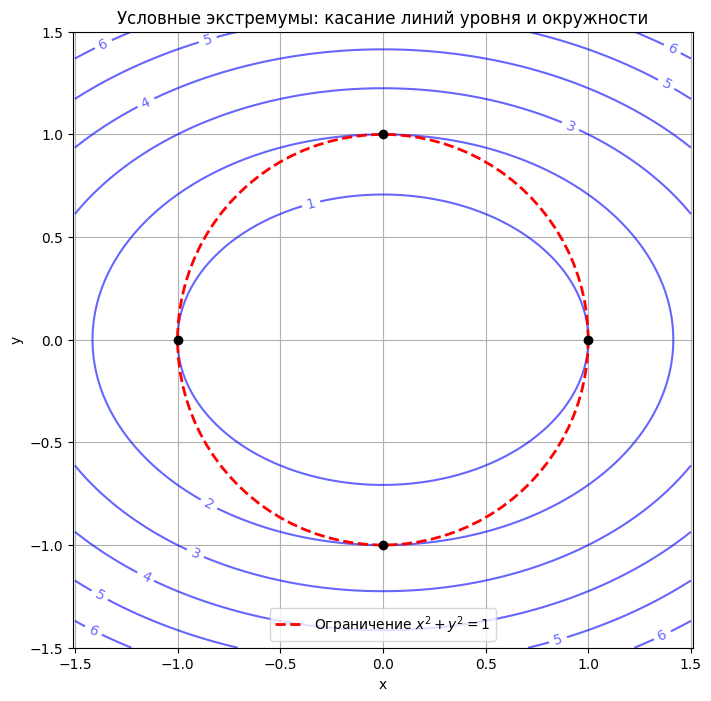

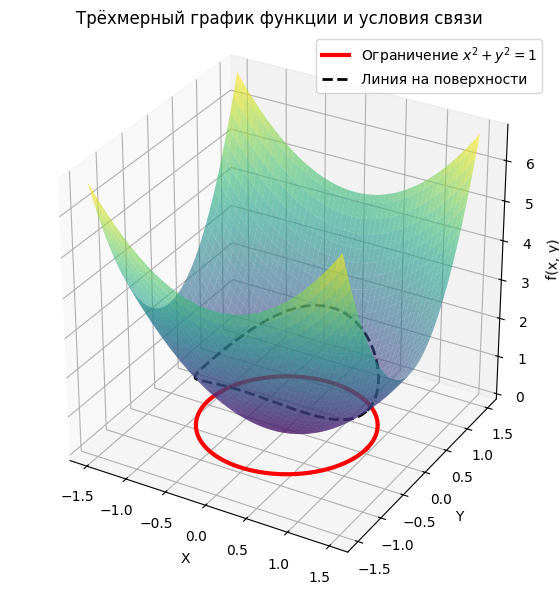

In [43]:
x, y, lam = sp.symbols('x y lambda')
f = x**2 + 2*y**2
g = x**2 + y**2 - 1
L = f - lam * g
eqs = [sp.diff(L, x), sp.diff(L, y), g]
sol = sp.solve(eqs, (x, y, lam), dict=True)

print("Точки условного экстремума:")
for s in sol:
    val = f.subs({x: s[x], y: s[y]})
    print(f"Точка: ({s[x]}, {s[y]}), Значение f: {val}")

x_vals = np.linspace(-1.5, 1.5, 400)
y_vals = np.linspace(-1.5, 1.5, 400)
X, Y = np.meshgrid(x_vals, y_vals)
Z = X**2 + 2*Y**2

plt.figure(figsize=(8, 8))
levels = np.arange(0, 10, 1)
cp = plt.contour(X, Y, Z, levels=levels, colors='blue', alpha=0.6)
plt.clabel(cp, inline=True, fontsize=10)

theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'r--', linewidth=2, label='Ограничение $x^2+y^2=1$')

for s in sol:
    plt.plot(float(s[x]), float(s[y]), 'ko')

plt.title('Условные экстремумы: касание линий уровня и окружности')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()
x = np.linspace(-1.5, 1.5, 100)
y = np.linspace(-1.5, 1.5, 100)
X, Y = np.meshgrid(x, y)
Z = X**2 + 2*Y**2

theta = np.linspace(0, 2*np.pi, 100)
cx = np.cos(theta)
cy = np.sin(theta)
cz = np.zeros_like(theta)  

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6, antialiased=True)
ax.plot(cx, cy, cz, color='red', linewidth=3, label='Ограничение $x^2+y^2=1$')
cz_on_surf = cx**2 + 2*cy**2
ax.plot(cx, cy, cz_on_surf, color='black', linewidth=2, linestyle='--', label='Линия на поверхности')
ax.set_box_aspect([1, 1, 1]) 
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')
ax.set_title('Трёхмерный график функции и условия связи')
ax.legend()

plt.show()